<a href="https://colab.research.google.com/github/mfarah737/clinical-data-analysis-diabetes-progression-factors/blob/main/Disease_Progression_in_Diabetes_Patients_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import libraries

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error



# Load dataset


In [ ]:

data = load_diabetes()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target



# Display dataset


In [ ]:
print(df.head())



        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


# Basic statistics


In [ ]:
print(df.describe())

                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.293722e-17  1.130318e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.

## Which variable is most strongly associated with disease progression?

target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64


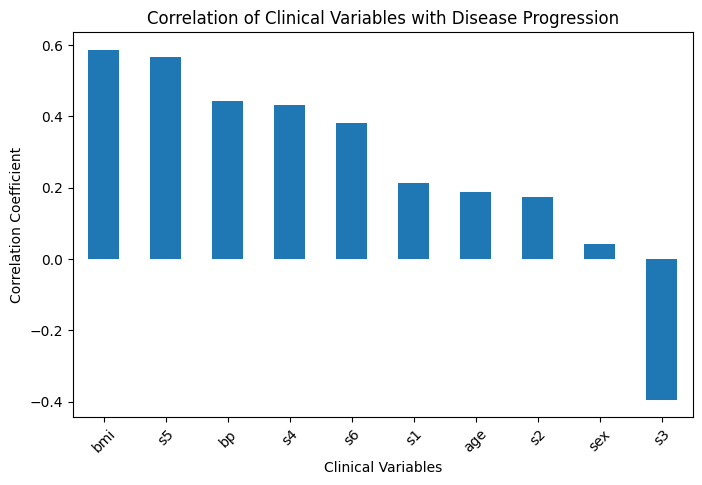

In [ ]:
# Correlation with target variable

correlation_target = df.corr()["target"].sort_values(ascending=False)

print(correlation_target)

# Plot correlations

plt.figure(figsize=(8,5))

correlation_target.drop("target").plot(kind="bar")

plt.title("Correlation of Clinical Variables with Disease Progression")

plt.xlabel("Clinical Variables")

plt.ylabel("Correlation Coefficient")

plt.xticks(rotation=45)

plt.show()

## **Result**:

Correlation analysis demonstrated that BMI showed the strongest positive association with disease progression (r = 0.586), followed by the clinical variable s5 (r = 0.566). Blood pressure also demonstrated moderate positive correlation (r = 0.441). In contrast, the variable s3 demonstrated a moderate negative correlation with disease progression (r = -0.395).

## **Discussion:**

These findings suggest that increased BMI may be associated with worsening disease progression in diabetes patients. The observed relationship aligns with existing clinical evidence linking obesity and metabolic dysfunction to adverse diabetes outcomes. Blood pressure also demonstrated moderate association, supporting the role of cardiovascular and metabolic factors in disease progression.

## What is the relationship between BMI and disease progression?

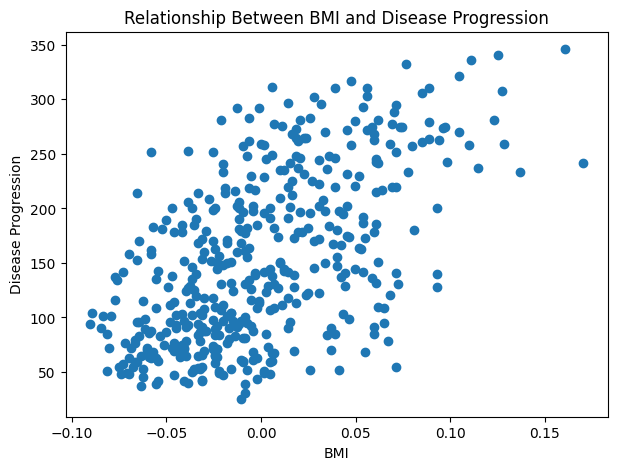

In [ ]:
# Scatter plot: BMI vs Disease Progression

plt.figure(figsize=(7,5))

plt.scatter(df["bmi"], df["target"])

plt.title("Relationship Between BMI and Disease Progression")

plt.xlabel("BMI")

plt.ylabel("Disease Progression")

plt.show()

## **Result:**

Scatter plot analysis demonstrated a positive relationship between BMI and disease progression. Higher BMI values were generally associated with increased disease progression scores. However, moderate variability was observed across patients, suggesting that additional clinical factors may also contribute to disease progression.

## **Discussion:**

The observed relationship between BMI and disease progression supports existing evidence linking obesity and metabolic dysfunction to adverse diabetes outcomes. Although BMI demonstrated strong association with progression, the variability observed in the data indicates that disease progression is likely influenced by multiple clinical and physiological factors.

## What is the distribution of disease progression scores, and are there any potential outliers?

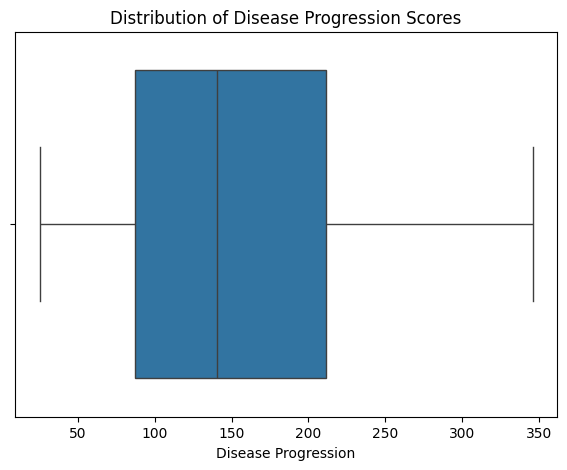

In [ ]:
# Distribution and outliers of disease progression

plt.figure(figsize=(7,5))

sns.boxplot(x=df["target"])

plt.title("Distribution of Disease Progression Scores")

plt.xlabel("Disease Progression")

plt.show()

## **Result:**

Boxplot analysis demonstrated moderate variability in disease progression scores across patients. Most values were concentrated within the mid-range distribution, while no extreme outliers were identified.

## **Discussion**

The absence of extreme outliers suggests that the dataset is relatively stable and suitable for exploratory clinical analysis. The observed variability in disease progression scores may reflect differences in patient-specific metabolic and clinical characteristics.

# Define features and target


In [ ]:
X = df.drop("target", axis=1)
y = df["target"]



# Train-test split


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



# Train model


## Linear Regression Model

In [ ]:


from sklearn.linear_model import LinearRegression

# Create model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

# Predictions
lr_pred = lr_model.predict(X_test)

# Evaluation
lr_r2 = r2_score(y_test, lr_pred)
lr_mae = mean_absolute_error(y_test, lr_pred)

print("Linear Regression Results")
print("-------------------------")
print("R2 Score:", round(lr_r2, 3))
print("Mean Absolute Error:", round(lr_mae, 3))

# Feature importance

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

print(coefficients.sort_values(by="Coefficient", ascending=False))

Linear Regression Results
-------------------------
R2 Score: 0.453
Mean Absolute Error: 42.794
  Feature  Coefficient
8      s5   736.198859
2     bmi   542.428759
5      s2   518.062277
3      bp   347.703844
7      s4   275.317902
6      s3   163.419983
9      s6    48.670657
0     age    37.904021
1     sex  -241.964362
4      s1  -931.488846


## RandomForestRegressor Model

In [ ]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train);

# Predictions
y_pred = model.predict(X_test)

# Model evaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("RandomForestRegressor Results")
print("-------------------------")
print("R2 Score:", round(r2, 3))
print("Mean Absolute Error:", round(mae, 3))

# Feature importance
importances = model.feature_importances_
features = X.columns



RandomForestRegressor Results
-------------------------
R2 Score: 0.443
Mean Absolute Error: 44.053



#  feature importance plot ( only for RandomForestRegressor Model)


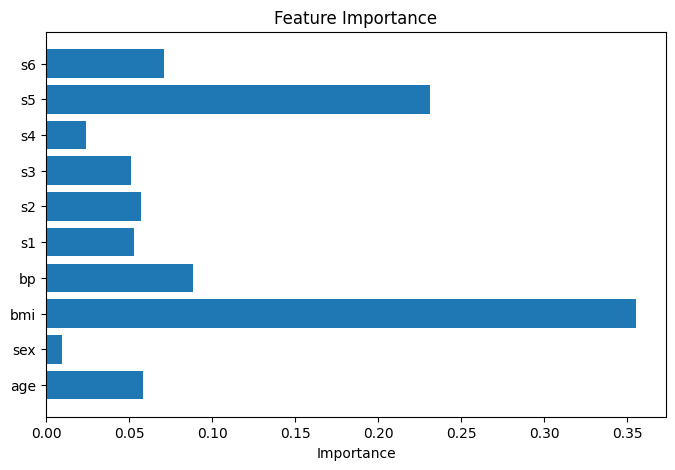

In [ ]:
plt.figure(figsize=(8,5))
plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()


**Model Comparison**

# **Model Comparison:**
# **Results**
## Model comparison demonstrated that the Linear Regression model slightly outperformed the Random Forest Regression model. Linear Regression achieved an R² score of 0.453 and a Mean Absolute Error (MAE) of 42.794, compared to an R² score of 0.443 and MAE of 44.053 for the Random Forest model.


# **Discussion**

## Although Random Forest models are capable of capturing complex non-linear relationships, the Linear Regression model demonstrated slightly superior predictive performance in this dataset. These findings may suggest that the relationships between the clinical variables and disease progression are relatively linear in nature.
## The comparison between machine learning and statistical regression approaches highlights the importance of selecting models based on dataset characteristics rather than model complexity alone.


## Although biological systems are inherently complex and often non-linear, the Linear Regression model demonstrated competitive performance in this dataset. This may suggest that the dominant relationships captured in the available variables can be approximated linearly, despite underlying physiological complexity.



# Correlation matrix


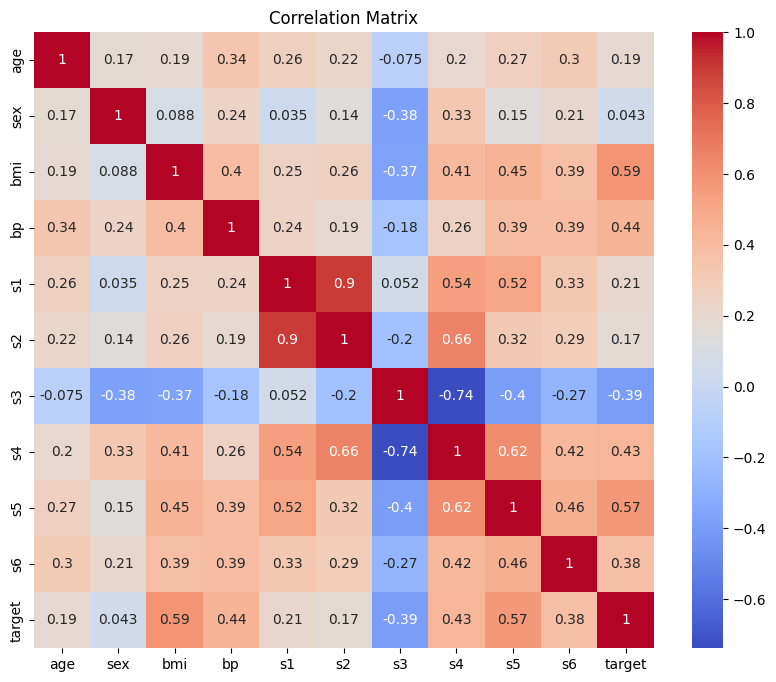

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Correlation matrix analysis was performed to evaluate relationships among clinical variables and disease progression. BMI and s5 demonstrated the strongest positive correlations with the target variable, supporting findings obtained from both the Linear Regression and Random Forest models.

# **Limitations:**

## Several limitations should be considered when interpreting these findings. The dataset used in this project was relatively small and intended primarily for educational purposes. Future analyses using larger and more diverse patient populations may provide more robust and generalizable conclusions.

# **Future work:**

## Future work could include larger clinical datasets and additional patient variables to improve model robustness and better capture the complexity of diabetes progression.